# 17. Dinâmicas de Género e o "Efeito Bolha"

**Objetivo:** Desconstruir o catálogo para entender quais os géneros narrativos que dominam o mercado, tanto em volume de produção como em avaliação do público, e testar a hipótese do "Efeito Bolha" em géneros de nicho.

### Perguntas de Negócio
1. **O Domínio da Produção:** Quais são os géneros mais produzidos/catalogados em cada mídia (O que a indústria mais entrega)?
2. **O Favoritismo do Público (Notas por Género):** Existe algum género que receba sistematicamente notas mais altas?
3. **O "Efeito Bolha" em Ação:** Géneros de nicho altamente segmentados (como Ficção Científica dura ou Fantasia Épica) apresentam anomalias nas suas notas devido a uma base de fãs extremamente fiel (Efeito Bolha)?

In [22]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Importação de Bibliotecas e Módulos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.io.data_save as ds
import src.io.db_client as dbc
import src.view.tables as tb
import src.view.plots as graf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Caminho central para a base de dados relacional


In [2]:
caminho_banco = '../../data/processed/unified_media_catalog.db'

---
## O Domínio da Produção

In [19]:
query_dominio = """
    SELECT 
        g.media_type,
        g.genres,
        COUNT(c.id) as volume_obras
    FROM unified_media_genres g
    INNER JOIN unified_media_catalog c ON g.id = c.id
    GROUP BY g.media_type, g.genres
    ORDER BY g.media_type ASC, volume_obras DESC;
"""

df_dominio = dbc.execute_query(
    caminho_banco,
    alvo=query_dominio,
    eh_query=True
)

# Top 10 Filmes
display(
    tb.estilizar_tabela(
        df=df_dominio[df_dominio['media_type'] == 'Movie'],
        qtd_linhas=10,
        caption='Top 10 Géneros mais frequentes no Cinema'
    )
    .bar(subset=['volume_obras'], color='#4C72B0')
)

# Top 10 Livros
display(
    tb.estilizar_tabela(
        df=df_dominio[df_dominio['media_type'] == 'Book'],
        qtd_linhas=10,
        caption='Top 10 Géneros mais frequentes na Literatura'
    )
    .bar(subset=['volume_obras'], color='#55A868')
)


Dados carregados via SQL! Formato: (873, 3)


,media_type,genres,volume_obras
852,Movie,Drama,21194
853,Movie,Comedy,13691
854,Movie,Thriller,8314
855,Movie,Romance,7179
856,Movie,Action,7143
857,Movie,Horror,5091
858,Movie,Crime,4674
859,Movie,Adventure,3827
860,Movie,Documentary,3536
861,Movie,Science Fiction,3347


,media_type,genres,volume_obras
0,Book,Fiction,9556
1,Book,Classics,4662
2,Book,Nonfiction,4356
3,Book,Literature,4020
4,Book,Novels,3552
5,Book,Fantasy,3528
6,Book,"Historical,Historical Fiction",2487
7,Book,History,2274
8,Book,Audiobook,2274
9,Book,Mystery,2178


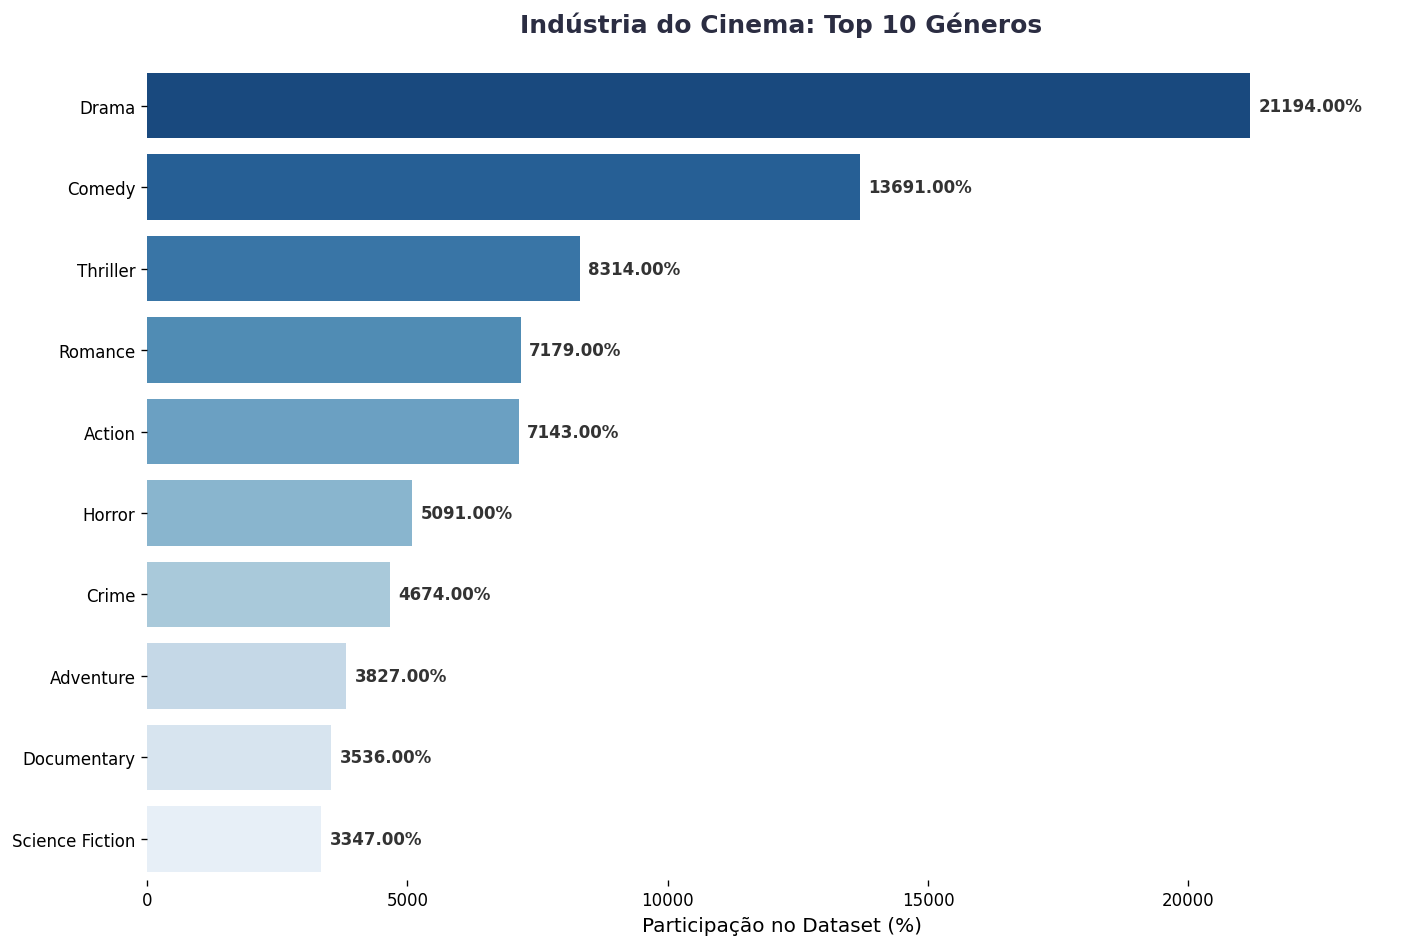

In [18]:
graf.grafico_top_categorias(
    df=df_dominio[df_dominio['media_type'] == 'Movie'],
    nome_coluna='genres',
    coluna_frequencia='volume_obras',
    top_n=10,
    titulo='Indústria do Cinema: Top 10 Géneros',
    palette='Blues_r'
)

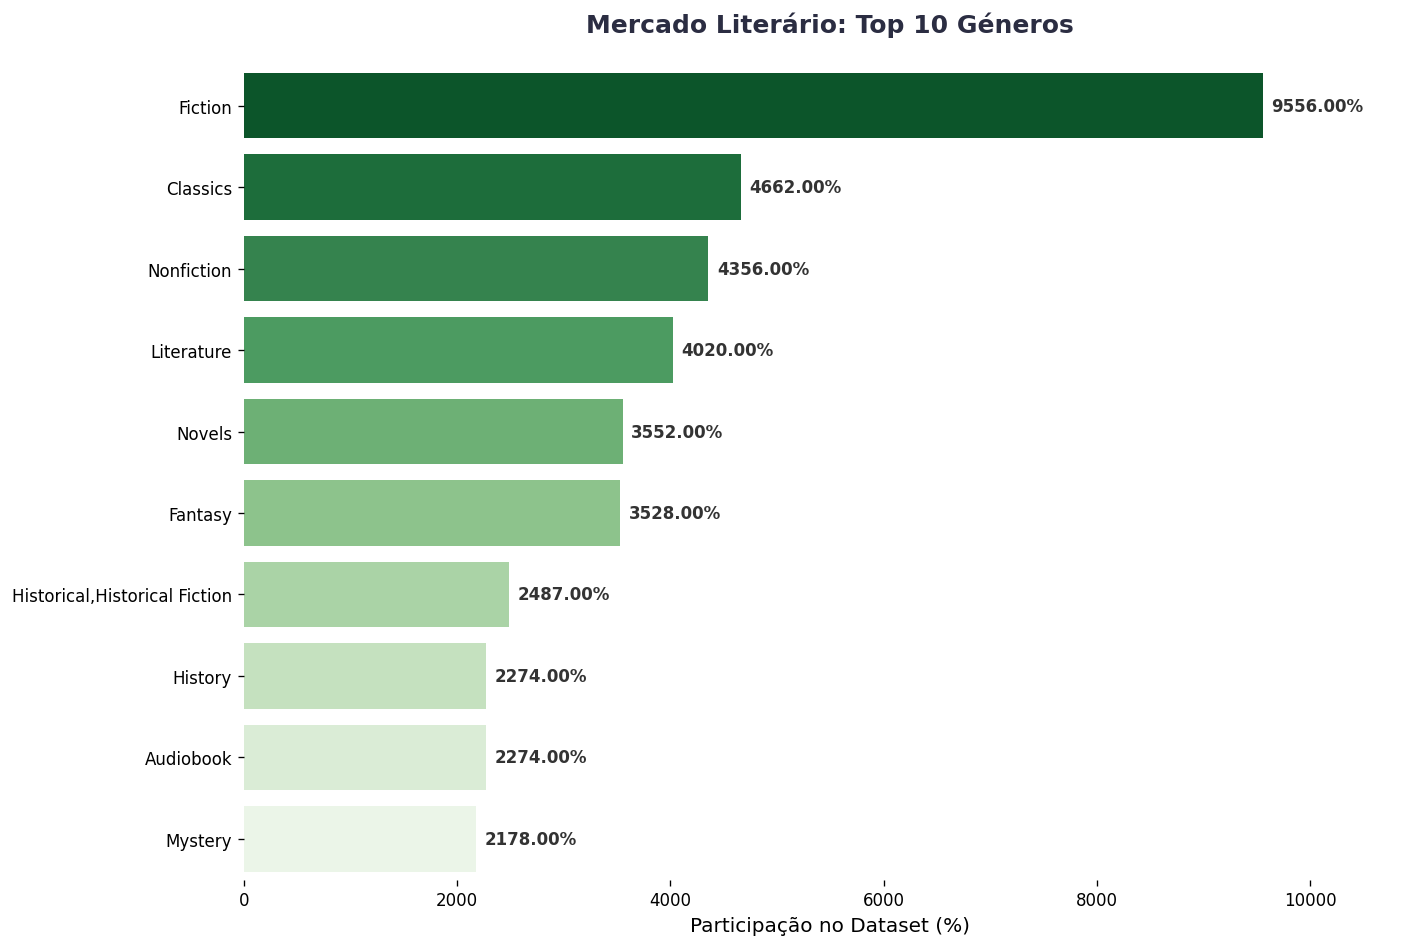

In [20]:
graf.grafico_top_categorias(
    df=df_dominio[df_dominio['media_type'] == 'Book'],
    nome_coluna='genres',
    coluna_frequencia='volume_obras',
    top_n=10,
    titulo='Mercado Literário: Top 10 Géneros',
    palette='Greens_r'
)

### O MARKET SHARE: COMPARAÇÃO PROPORCIONAL DE GÉNEROS COMUNS

In [21]:
# Calculo do total de obras por mídia para descobrirmos a percentagem
total_por_midia = df_dominio.groupby('media_type')['volume_obras'].sum()

# Ciração da coluna de percentagem (Market Share)
df_pct = df_dominio.copy()
df_pct['frequencia_pct'] = df_pct.apply(
    lambda row: (row['volume_obras'] / total_por_midia[row['media_type']]) * 100, 
    axis=1
)

# Comparação de géneros em comum (Pivot Table)
df_pivot = df_pct.pivot(
    index='genres', 
    columns='media_type', 
    values='frequencia_pct'
)

df_comuns = df_pivot.dropna().copy()

df_comuns['relevancia_total'] = df_comuns['Book'] + df_comuns['Movie']
df_top_comuns = df_comuns.sort_values('relevancia_total', ascending=False).head(10)

# Remover a coluna de soma e voltar ao formato normal para o gráfico
df_top_comuns = df_top_comuns.drop(columns=['relevancia_total']).reset_index()
df_plot_comuns = df_top_comuns.melt(id_vars='genres', var_name='media_type', value_name='pct')


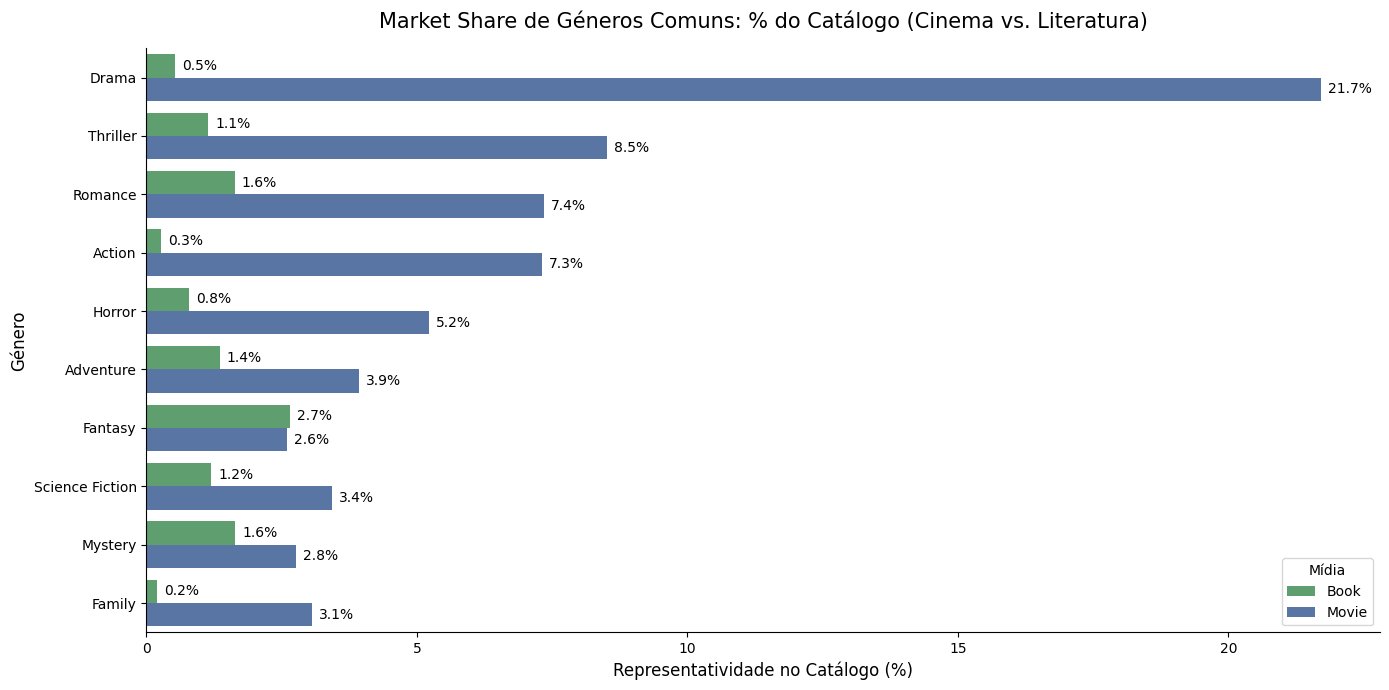

In [23]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_plot_comuns, 
    x='pct', 
    y='genres', 
    hue='media_type', 
    palette={'Movie': '#4C72B0', 'Book': '#55A868'}
)

plt.title('Market Share de Géneros Comuns: % do Catálogo (Cinema vs. Literatura)', fontsize=15, pad=15)
plt.xlabel('Representatividade no Catálogo (%)', fontsize=12)
plt.ylabel('Género', fontsize=12)
plt.legend(title='Mídia')

# Adicionar os valores exatos no final de cada barra
for ax in plt.gca().containers:
    plt.gca().bar_label(ax, fmt='%.1f%%', padding=5, fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()